<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>INTELIGÊNCIA ARTIFICIAL - Trabalho 3</center></h1>

- Nome completo: <João Pedro Jendiroba Paixão Corrêa>
- [Link para vídeo](<https://youtu.be/hPZiCM5I0o4>)

## 2. Redes Neurais MLP com PyTorch (2 pts)

### 2.1 Parte A – Classificação

#### 2.1.1 EDA

Primeiras amostras do dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines

C:\Users\joaopjpc\AppData\Local\Temp\ipykernel_24280\1145872398.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


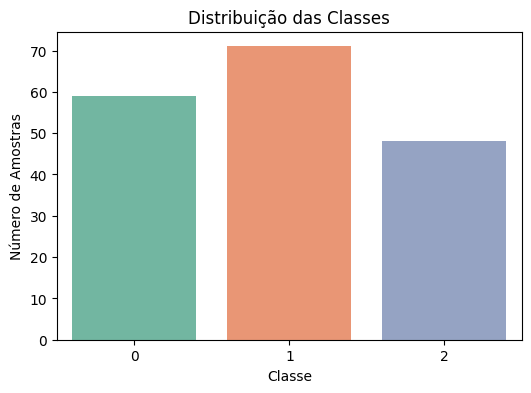

C:\Users\joaopjpc\AppData\Local\Temp\ipykernel_24280\1145872398.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')


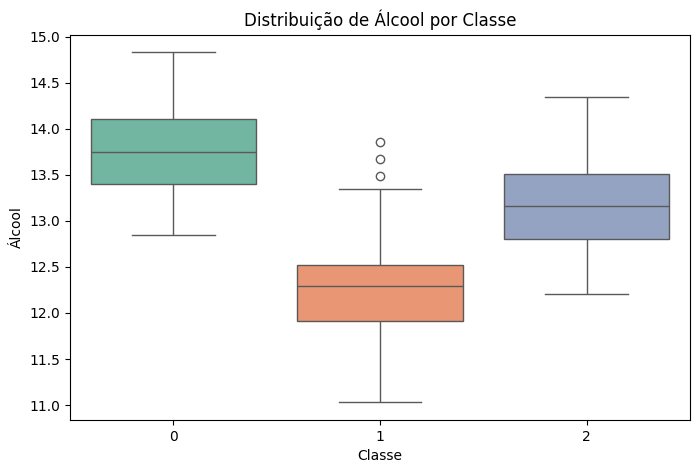

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Carregar o dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# 1. Exibir as primeiras amostras
print("Primeiras amostras do dataset:")
print(df.head())

# 2. Ver distribuição das classes
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Número de Amostras")
plt.show()

# 3. Boxplot da feature 'alcohol' por classe
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='alcohol', data=df, palette='Set2')
plt.title("Distribuição de Álcool por Classe")
plt.xlabel("Classe")
plt.ylabel("Álcool")
plt.show()
print(df.describe())


#### 2.1.2 Pré Processamento



In [2]:
# 1. Importação 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 2. Carregamento e divisão 
X, y = load_wine(return_X_y=True)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


# 3. Normalização para igualar as escalas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # .fit_transform ajusta o scaler com dados de treino e transforma todos os outros dados
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Exibição das dimensões e primeiras linhas
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Primeiras linhas de X_train:\n", X_train[:5])
print("Primeiros valores de y_train:", y_train[:10])

X_train shape: (106, 13)
X_val shape: (36, 13)
X_test shape: (36, 13)
Primeiras linhas de X_train:
 [[ 0.95817987 -0.68509096  1.2406911   0.00903313  2.06926091  1.08120553
   0.78503623  1.20204481 -0.44822156  0.12419372  1.24696915  0.63687539
   1.52698895]
 [-0.35275089 -1.21898754 -0.41265949 -0.48623138 -0.1109423  -0.12790742
  -0.05317924 -0.49797854 -0.25906979 -1.01378527  1.16178598  0.87484425
  -0.97042148]
 [ 0.74169589 -0.55889723  0.01864936 -0.12303741  0.35152505  0.93611197
   1.25653243 -1.17798787  0.58351536  0.73821116  0.56550377  0.45839874
   2.41778503]
 [ 1.07844875 -0.70450539  1.13286389  1.82500297 -0.96981023  1.08120553
   0.91076855 -1.26298904  0.44595044 -0.7026831   1.71547661  0.87484425
  -1.09767806]
 [ 0.10427085 -0.18031601  3.10969612  1.82500297  1.5407268   0.56531734
   0.72217007  0.94704131  0.53192851 -0.62081411  0.73587011  0.93433647
   0.23851605]]
Primeiros valores de y_train: [0 1 0 1 0 0 2 0 1 0]


#### 2.1.3 Conversão para tensor 

In [3]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


#### 2.1.4 Definição de modelo MLP pra classificação

In [4]:
import torch.nn as nn

class MLP(nn.Module): # Definição de uma rede neural simples (MLP) com uma camada oculta
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(X.shape[1], 32) # X.shape[1] é o número de features e 32 é o número de neurônios na camada oculta 
        self.relu = nn.ReLU() # Função de ativação ReLU para introduzir não-linearidade
        self.output = nn.Linear(32, 3)  # 3 classes no wine

    def forward(self, x): # Método de propagação direta
        x = self.relu(self.hidden(x)) # Aplica a camada oculta seguida da função de ativação ReLU
        return self.output(x) # Retorna a saída bruta da camada final, que produz logits para as 3 classes

model = MLP()


#### 2.1.5 Treinamento

In [6]:
# Adam usa Momentum (velocidade de mudança dos pesos) e RMSprop (ajuste do passo com base no histórico do gradiente).
import torch.optim as optim # Otimizador Adam para atualizar os pesos da rede neural
import torch.nn as nn # Biblioteca para construir redes neurais em PyTorch
import numpy as np # Biblioteca para operações numéricas em Python

loss_fn = nn.CrossEntropyLoss() # Função de perda de entropia cruzada para classificação multiclasse
optimizer = optim.Adam(model.parameters(), lr=0.01) # Otimizador Adam para atualizar os pesos da rede neural lr = taxa de aprendizado
losses = [] # Lista para armazenar as perdas durante o treinamento

probs = [] # Lista para armazenar as probabilidades previstas durante o treinamento
correct = [] # Lista para armazenar as previsões corretas durante o treinamento

for epoch in range(50): # Treinamento por 50 
    model.train() # Muda o modelo para o modo de treinamento
    outputs = model(X_train_t) # Propagação direta: calcula as previsões da rede neural para os dados de treino
    loss = loss_fn(outputs, y_train_t) # Calcula a perda entre as previsões e os rótulos reais
    losses.append(loss.item()) # Armazena a perda para análise posterior

    # Backpropagation: calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.zero_grad() # Zera os gradientes acumulados do otimizador
    loss.backward() # Calcula os gradientes da perda em relação aos pesos da rede neural
    optimizer.step() # Atualiza os pesos da rede neural com base nos gradientes calculados

    with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a computação
        pred_probs = torch.softmax(outputs, dim=1).cpu().numpy() # Calcula as probabilidades previstas usando a função softmax
        epoch_probs = pred_probs[np.arange(len(y_train)), y_train] # Extrai as probabilidades correspondentes às classes reais
        probs.append(epoch_probs) # Armazena as probabilidades previstas para análise posterior

        preds = np.argmax(pred_probs, axis=1) # Obtém as classes previstas pela rede neural, escolhendo a classe com a maior probabilidade
        epoch_correct = (preds == y_train).astype(int) # Compara as classes previstas com as classes reais e converte o resultado em 0s e 1s (0 para incorreto, 1 para correto)
        correct.append(epoch_correct) # Armazena as previsões corretas para análise posterior


#### 2.1.6 Avaliação

In [7]:
model.eval() # Muda o modelo para o modo de avaliação, desativando dropout e batch normalization 
with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a inferência
    pred = model(X_test_t).argmax(dim=1) # Obtém as previsões da rede neural para os dados de teste e seleciona a classe com maior probabilidade
    accuracy = (pred == y_test_t).float().mean().item() # Calcula a acurácia como a proporção de previsões corretas
    print(f"Acurácia no teste: {accuracy * 100:.2f}%") # Exibe a acurácia no conjunto de teste


Acurácia no teste: 97.22%


#### 2.1.7 Curva de perda

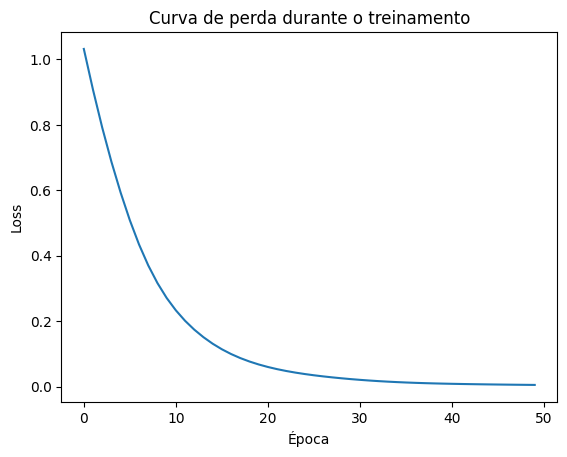

In [8]:
plt.plot(losses)
plt.title("Curva de perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()
